[*********************100%***********************]  1 of 1 completed


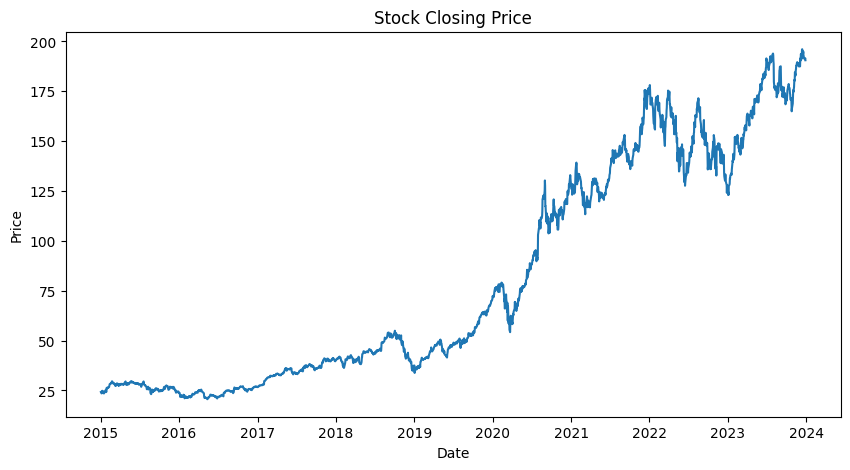

c:\Users\Akshunn Garg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 0.0197
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0036
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0030
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0030
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0026
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0028
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0027
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0024
Epoch 9/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0020
Epoch 10/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0021
Epoch 11/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0021
Epoch 12/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0020
Epoch 13/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0021
Epoch 14/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0022
Epoch 15/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0019
Epoc

[*********************100%***********************]  1 of 1 completed


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


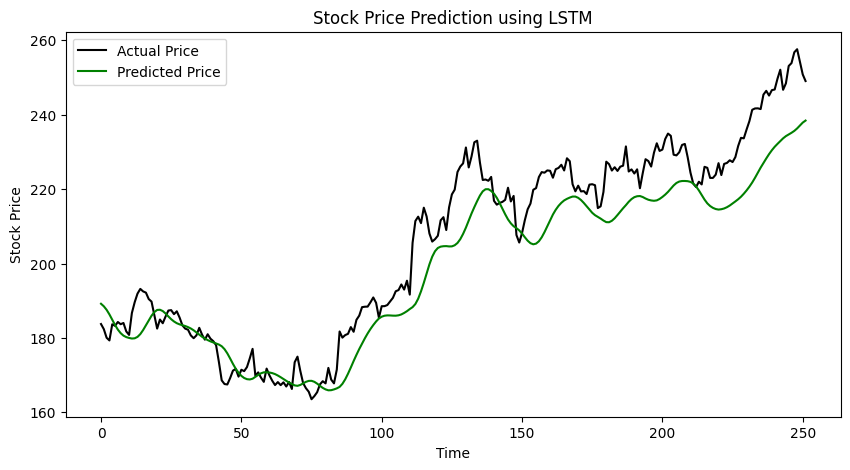

In [3]:
# LSTM for Stock Price Prediction using Yahoo Financial Historical Dataset

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Download stock data
data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
data = data[['Close']]

# Plot original data
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# Create training dataset
x_train, y_train = [], []
for i in range(60, len(scaled_data)):
    x_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
model.fit(x_train, y_train, epochs=20, batch_size=32)

# Load test data
test_data = yf.download("AAPL", start="2024-01-01", end="2025-01-01")
actual_prices = test_data[['Close']]

# Prepare inputs
total_dataset = pd.concat((data['Close'], test_data['Close']), axis=0)
model_inputs = total_dataset[len(total_dataset) - len(test_data) - 60:].values
model_inputs = model_inputs.reshape(-1,1)
model_inputs = scaler.transform(model_inputs)

# Create test sequences
x_test = []
for i in range(60, len(model_inputs)):
    x_test.append(model_inputs[i-60:i,0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Predict
predicted_prices = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted_prices)

# Plot results
plt.figure(figsize=(10,5))
plt.plot(actual_prices.values, color='black', label='Actual Price')
plt.plot(predicted_prices, color='green', label='Predicted Price')
plt.title("Stock Price Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()
